## Setting

In [99]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [100]:
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 13.6 gigabytes of available RAM

Not using a high-RAM runtime


In [101]:
!pip install nltk
!pip install -U pandas-profiling
!pip install pydantic
!pip install umap-learn
!pip install factor_analyzer
!pip install typing-extensions --upgrade

### Importing Dependencies

In [102]:
import string
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import ydata_profiling

from scipy.sparse import csr_matrix

from sklearn.cluster import SpectralClustering
from sklearn.decomposition import PCA, LatentDirichletAllocation, NMF
from sklearn.feature_selection import chi2, f_classif, SelectKBest
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, TfidfTransformer
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler, RobustScaler, Normalizer, normalize


from wordcloud import WordCloud

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer, PorterStemmer
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

stemmer = PorterStemmer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### Data Load

In [103]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/pilot_data.csv")
print("초기 Document 수 :", data.shape[0])

초기 Document 수 : 1000


In [104]:
# simple EDA
# data.profile_report()

## STEP 1 : Finding the core vecotr space

### Data Cleaning

In [105]:
# delected data where the abstract or title information was missing or was a duplicate

data.dropna(subset=['Abstract', 'Article Title'], inplace=True)
data.drop_duplicates(subset=['Article Title', 'Abstract'], inplace=True)

print("초록, 제목  Null 값 제거 & 중복 제거")
print("Data Cleaning 후 Document 수 :", data.shape[0])

초록, 제목  Null 값 제거 & 중복 제거
Data Cleaning 후 Document 수 : 997


In [106]:
# Data Transformation
def combine_3rd_columns(col_1, col_2, col_3):

    result = col_1

    if not pd.isna(col_2):
        result += " " + str(col_2)

    if not pd.isna(col_3):
        result += " " + str(col_3)

    return result

data["text"] = data.apply(lambda x: combine_3rd_columns(x['Article Title'], x['Abstract'], x['Author Keywords']), axis=1)
data.drop(data[(data['text'] == " ")].index, inplace=True) # text가 남아있지 않은 row 삭제

df = data.loc[:, ['text', 'Article Title']]
print("Data Transformation 후 Document 수 :", df.shape[0])

Data Transformation 후 Document 수 : 997


### Data preprocessing

In [107]:
def preprocess_text(text):

    words = nltk.word_tokenize(text)

    original_words = []
    lemmatized_words = []

    words = [token for token in words if token not in string.punctuation]

    for word in words:
        word = word.lower()

        if word not in stop_words and not word.isdigit() :
            lemma = lemmatizer.lemmatize(word)
            lemmatized_words.append(lemma)

            if word != lemma :
                original_words.append({word : lemma})

    processed_text = ' '.join([token for token in lemmatized_words])

    return processed_text, original_words

df['processed_data'] = df['text'].apply(preprocess_text)

df[['corpus', 'lemma_pairs']] = pd.DataFrame(df['processed_data'].tolist(), index=df.index)

df.drop(columns=['processed_data', 'text'], inplace=True)
df.head()

,Article Title,corpus,lemma_pairs
0,A Framework of Smart-Home Service for Elderly'...,framework smart-home service elderly 's biophi...,"[{'services': 'service'}, {'supports': 'suppor..."
1,Service Provisioning Framework for Digital Sma...,service provisioning framework digital smart h...,"[{'services': 'service'}, {'services': 'servic..."
2,Analysis of Types and Importance of Sensors in...,analysis type importance sensor smart home ser...,"[{'types': 'type'}, {'sensors': 'sensor'}, {'s..."
3,Smart Home Services Based on Event Matching,smart home service based event matching smart ...,"[{'services': 'service'}, {'technologies': 'te..."
4,A Proposal for an Integrated Smart Home Servic...,proposal integrated smart home service platfor...,"[{'devices': 'device'}, {'consumers': 'consume..."


##### Customized rules : do not lemmatize “glasses” to “glass”



In [108]:
# find do not lemmatize
check_list = df.loc[:, ['lemma_pairs']]
combined_list = check_list['lemma_pairs'].sum()

def remove_duplicates(lst):
    result = []
    for item in lst:
        if item not in result:
            result.append(item)
    return result

unique_ordered_list  = remove_duplicates(combined_list)
keys, values = [], []

for d in unique_ordered_list:
    for key, value in d.items():
        keys.append(key)
        values.append(value)

checks = pd.DataFrame({'Key': keys, 'Value': values})
checks.drop_duplicates(subset=['Key'], inplace=True)
checks.drop_duplicates(subset=['Value'], inplace=True)

def check_meaning(word):
    singular = wordnet.synsets(word)
    plural = wordnet.synsets(word + 's')

    if singular and plural:
        if singular[0].definition() != plural[0].definition():
            return (True, f"'{word}': {singular[0].definition()}", f"'{word}s': {plural[0].definition()}")

    return (False, None, None)

checks['is_different'], checks['singular_def'], checks['plural_def'] = zip(*checks['Value'].map(check_meaning))
checks[checks['is_different']].to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/customized(not_lemmatize).csv', index=False)

In [109]:
df = df.loc[:, ['corpus', 'Article Title']]
df.drop(df[(df['corpus'] == " ")].index, inplace=True) # corpus 남아있지 않은 row 삭제

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['corpus'])
feature_names = tfidf_vectorizer.get_feature_names_out()

print("전처리 후 Document 갯수:",tfidf_matrix.shape[0])
print("전처리 후 초기 word-feature 갯수:",tfidf_matrix.shape[1])

전처리 후 Document 갯수: 997
전처리 후 초기 word-feature 갯수: 7654


### 1. Deciding on the number of keywords to be selected from each item

In [110]:
# visualization function
def plot_keywords(x, y, y_label, title):

    plt.style.use('seaborn-whitegrid')
    plt.figure(figsize=(10,6))

    plt.plot(x, y,  marker='o', color = 'b')

    plt.gca().invert_xaxis()

    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)

    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.gca().set_facecolor('lightgray')
    plt.grid(color='white', linestyle='-', linewidth=1)

    k_formatter = FuncFormatter(lambda x, pos: f'K{x}')
    plt.gca().xaxis.set_major_formatter(k_formatter)

    plt.xticks(range(min(keyword_counts), max(keyword_counts)+1))

    plt.xlabel('Number of selected top keywords from each data')
    plt.ylabel(y_label)

    for i in [4, 5]:
        if i in x:
            index = x.index(i)
            plt.plot(i, y[index], marker='o', color='y')

    plt.title(title)
    plt.show()

In [111]:
keyword_counts = list(range(20, 1, -1))

tfidf_matrix_transposed = tfidf_matrix.toarray()

##### Metric 1 : Mean of the TF-IDF scores of a word-feature across data

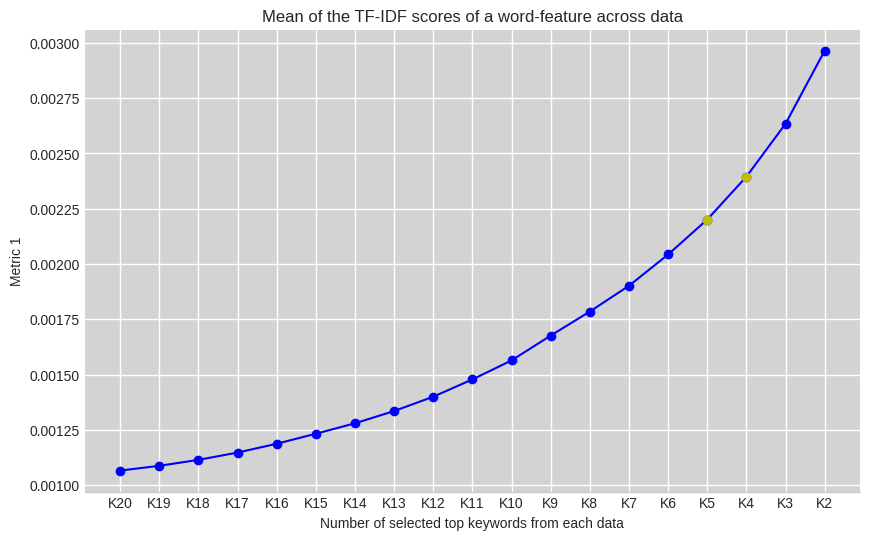

In [112]:
mean_tfidf_scores = []

for count in keyword_counts:
    top_keywords = []

    for doc_idx in range(len(df)):
        tfidf_scores = tfidf_matrix[doc_idx].toarray()[0]
        top_indices = np.argsort(tfidf_scores)[-count:]
        top_keywords.extend([feature_names[idx] for idx in top_indices])
    top_keywords = list(set(top_keywords))

    keyword_indices = [np.where(np.array(feature_names) == keyword)[0][0] for keyword in top_keywords]
    keyword_tfidf_scores = tfidf_matrix[:, keyword_indices].toarray()

    # TF-IDF score 평균 계산
    mean_tfidf_score = np.mean(keyword_tfidf_scores)
    mean_tfidf_scores.append(mean_tfidf_score)

plot_keywords(keyword_counts, mean_tfidf_scores, 'Metric 1',  'Mean of the TF-IDF scores of a word-feature across data')

##### Metric 2 : Mean of the cosine similarities of a word-feature to other features

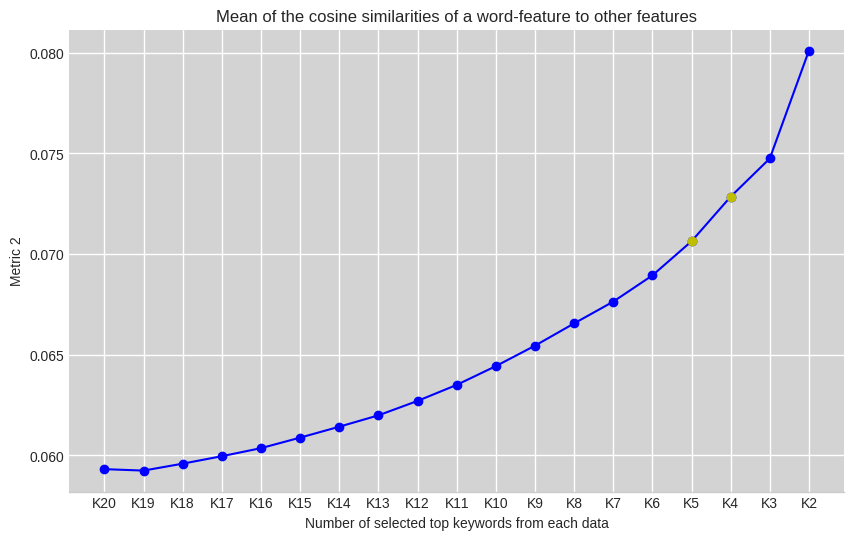

In [113]:
mean_cosine_similarities = []

for num_keywords in keyword_counts:
    top_keywords = []

    for doc_idx in range(len(df)):
        tfidf_scores = tfidf_matrix[doc_idx].toarray()[0]
        top_indices = np.argsort(tfidf_scores)[-num_keywords:]
        top_keywords.extend([feature_names[idx] for idx in top_indices])

    top_keywords = list(set(top_keywords))

    keyword_indices = [np.where(np.array(feature_names) == keyword)[0][0] for keyword in top_keywords]
    keyword_matrix = tfidf_matrix[:, keyword_indices]
    cosine_similarities = cosine_similarity(keyword_matrix)

    mean_cosine_similarity = np.mean(cosine_similarities)
    mean_cosine_similarities.append(mean_cosine_similarity)

plot_keywords(keyword_counts, mean_cosine_similarities,'Metric 2', 'Mean of the cosine similarities of a word-feature to other features')

##### Metric 3 : Cosine similarity between a word-feature and the centroid of features

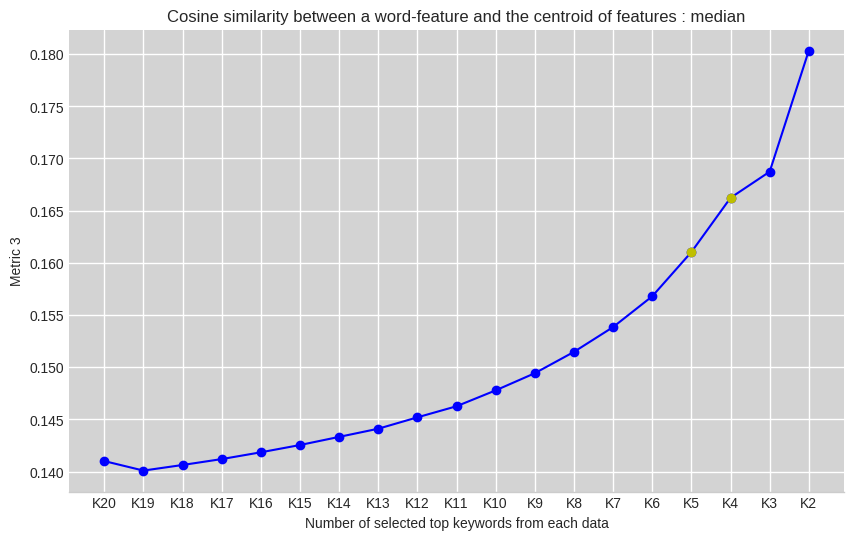

In [114]:
median_cosine_similarities = []

for count in keyword_counts:
    top_keywords = []

    for doc_idx in range(len(df)):
        tfidf_scores = tfidf_matrix[doc_idx].toarray()[0]
        top_indices = np.argsort(tfidf_scores)[-count:]
        top_keywords.extend([feature_names[idx] for idx in top_indices])

    top_keywords = list(set(top_keywords))

    keyword_indices = [np.where(np.array(feature_names) == keyword)[0][0] for keyword in top_keywords]
    keyword_matrix = tfidf_matrix[:, keyword_indices]


    centroid_features = np.median(keyword_matrix.toarray(), axis=0)
    cosine_similarities = cosine_similarity(keyword_matrix.toarray(), centroid_features.reshape(1, -1))

    mean_cosine_similarity = np.mean(cosine_similarities)
    median_cosine_similarities.append(mean_cosine_similarity)

plot_keywords(keyword_counts, median_cosine_similarities, "Metric 3", "Cosine similarity between a word-feature and the centroid of features : median")

##### Metric 4 : Mean of the dot product scores of a word-feature to other features

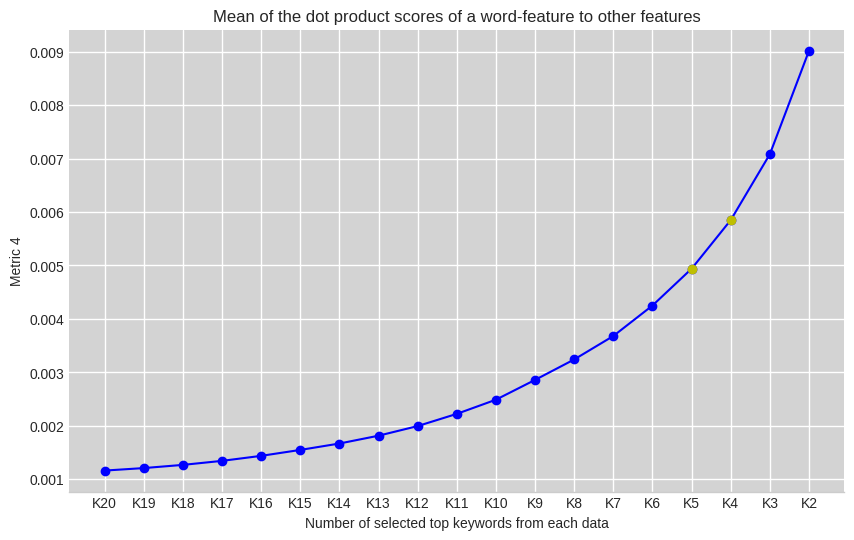

In [115]:
mean_dot_product_scores = []

for count in keyword_counts:
    top_keywords = []

    for doc_idx in range(len(df)):
        tfidf_scores = tfidf_matrix[doc_idx].toarray()[0]
        top_indices = np.argsort(tfidf_scores)[-count:]
        top_keywords.extend([feature_names[idx] for idx in top_indices])

    top_keywords = list(set(top_keywords))

    keyword_indices = [np.where(np.array(feature_names) == keyword)[0][0] for keyword in top_keywords]
    keyword_tfidf_scores = tfidf_matrix[:, keyword_indices].toarray()
    dot_product_scores = np.dot(keyword_tfidf_scores.T, keyword_tfidf_scores)

    mean_dot_product_score = np.mean(dot_product_scores)
    mean_dot_product_scores.append(mean_dot_product_score)

plot_keywords(keyword_counts, mean_dot_product_scores,"Metric 4", "Mean of the dot product scores of a word-feature to other features")

##### Metric 5 : LDA score of a word-feature for the single topic of entire data set

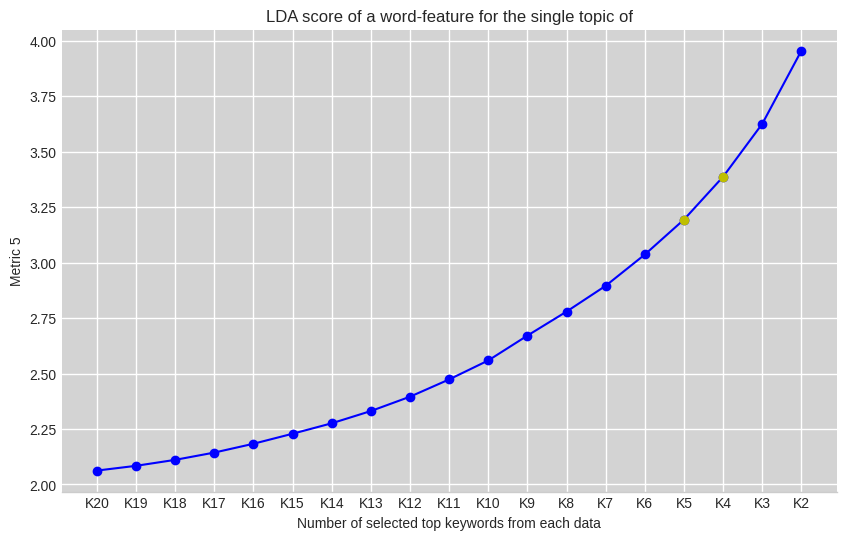

In [116]:
lda_model = LatentDirichletAllocation(n_components=1, random_state=0)
lda_model.fit(tfidf_matrix)

mean_lda_scores = []

for count in keyword_counts:
    top_keywords = []

    for doc_idx in range(len(df)):
        tfidf_scores = tfidf_matrix[doc_idx].toarray()[0]
        top_indices = np.argsort(tfidf_scores)[-count:]
        top_keywords.extend([feature_names[idx] for idx in top_indices])

    top_keywords = list(set(top_keywords))

    num_topics = 1
    lda_model = LatentDirichletAllocation(n_components=num_topics)
    lda_model.fit(tfidf_matrix)

    lda_scores = lda_model.components_

    keyword_indices = [np.where(np.array(feature_names) == keyword)[0][0] for keyword in top_keywords]
    keyword_lda_scores = lda_scores[:, keyword_indices]

    mean_lda_score = np.mean(keyword_lda_scores)
    mean_lda_scores.append(mean_lda_score)

plot_keywords(keyword_counts, mean_lda_scores,"Metric 5", "LDA score of a word-feature for the single topic of")

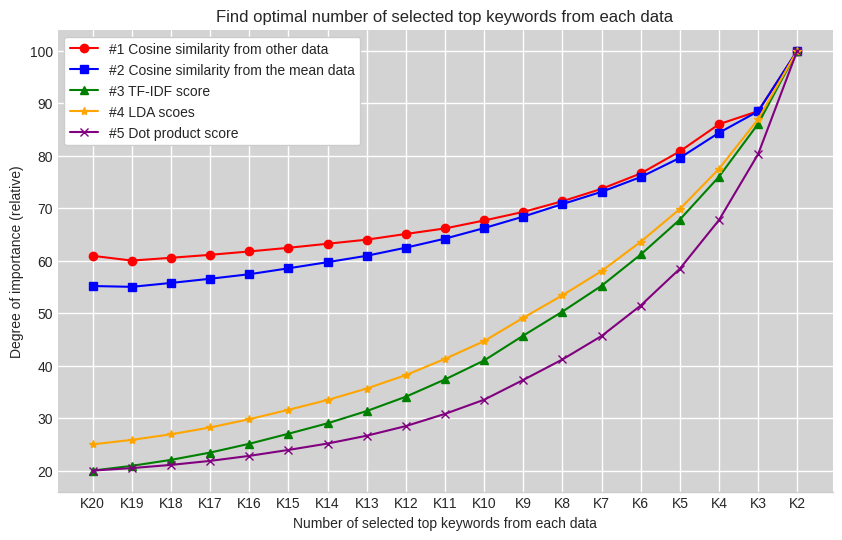

In [117]:
metric1_values = median_cosine_similarities
metric2_values = mean_cosine_similarities
metric3_values = mean_tfidf_scores
metric4_values = mean_lda_scores
metric5_values = mean_dot_product_scores

metric1_normalized = (metric1_values - np.min(metric1_values)) / (np.max(metric1_values) - np.min(metric1_values)) * 40 + 60
metric2_normalized = (metric2_values - np.min(metric2_values)) / (np.max(metric2_values) - np.min(metric2_values)) * 45 + 55
metric3_normalized = (metric3_values - np.min(metric3_values)) / (np.max(metric3_values) - np.min(metric3_values)) * 80 + 20
metric4_normalized = (metric4_values - np.min(metric4_values)) / (np.max(metric4_values) - np.min(metric4_values)) * 75 + 25
metric5_normalized = (metric5_values - np.min(metric5_values)) / (np.max(metric5_values) - np.min(metric5_values)) * 80 + 20

plt.style.use('seaborn-whitegrid')
plt.figure(figsize=(10,6))

plt.gca().invert_xaxis()

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.gca().set_facecolor('lightgray')

plt.xticks(range(min(keyword_counts), max(keyword_counts)+1))

k_formatter = FuncFormatter(lambda x, pos: f'K{x}')

plt.gca().xaxis.set_major_formatter(k_formatter)
plt.grid(color='white', linestyle='-', linewidth=1)
plt.xlabel('Number of selected top keywords from each data')
plt.ylabel('Degree of importance (relative)')

plt.plot(keyword_counts, metric1_normalized, marker='o', label='#1 Cosine similarity from other data', color='red')
plt.plot(keyword_counts, metric2_normalized, marker='s', label='#2 Cosine similarity from the mean data', color='blue')
plt.plot(keyword_counts, metric3_normalized, marker='^', label='#3 TF-IDF score', color='green')
plt.plot(keyword_counts, metric4_normalized, marker='*', label='#4 LDA scoes', color='orange')
plt.plot(keyword_counts, metric5_normalized, marker='x', label='#5 Dot product score', color='purple')

plt.xlabel('Number of selected top keywords from each data')
plt.ylabel('Degree of importance (relative)')
plt.title('Find optimal number of selected top keywords from each data')
plt.legend(frameon = True, framealpha=1)

plt.show()

##### Result

In [118]:
# Items 당 상위 4개의 단어 선택 - Type 3 제거
top_keywords_per_document = []
feature_names = tfidf_vectorizer.get_feature_names_out()

for i in range(len(df)):
    tfidf_scores = zip(feature_names, tfidf_matrix[i].toarray()[0])
    sorted_tfidf_scores = sorted(tfidf_scores,key=lambda x: x[1], reverse=True)

    top_keywords_per_document.append([keyword for keyword,_ in sorted_tfidf_scores[:5]])

# 전체 데이터셋에서 적어도 2번 이상 나온 키워드 추출하기 - Type 1 제거
all_keywords=[keyword for document in top_keywords_per_document for keyword in document]
selected_keywords=list(set(keyword for keyword in all_keywords if all_keywords.count(keyword) >=2))

vectorizer = TfidfVectorizer(vocabulary=selected_keywords)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])

print("현재 Document 갯수:",tfidf_matrix.shape[0])
print("현재 word-feature 갯수:",tfidf_matrix.shape[1])

현재 Document 갯수: 997
현재 word-feature 갯수: 700


### 2. Word_featuring Clustering based on Gaussian mixture model (GMM)

In [119]:
vectorizer = TfidfVectorizer(vocabulary=selected_keywords)

tfidf_matrix = vectorizer.fit_transform(df['corpus'])

feature_names = vectorizer.get_feature_names_out()

tfidf_matrix_transposed = tfidf_matrix.T.toarray()

In [120]:
from collections import defaultdict

feature_names = vectorizer.get_feature_names_out()

# memory issue
tfidf_matrix = tfidf_matrix.astype('float32')
tfidf_matrix_transposed = tfidf_matrix.T.toarray()

union_keywords_set = None
intersection_keywords_set = None

keyword_frequency = defaultdict(int)

# GMM based Clustering
for i in range(10):

    gmm = GaussianMixture(n_components=100, covariance_type='diag')
    gmm.fit(tfidf_matrix_transposed)

    cluster_labels = gmm.predict(tfidf_matrix_transposed)

    df_clustered_keywords = pd.DataFrame(feature_names, columns=['keyword'])
    df_clustered_keywords['cluster'] = cluster_labels

    cluster_counts = df_clustered_keywords['cluster'].value_counts()
    max_data_pointer_cluster_labels = cluster_counts.nlargest(2).index.tolist()
    max_data_pointer_cluster = df_clustered_keywords[df_clustered_keywords['cluster'].isin(max_data_pointer_cluster_labels)]['keyword'].values.tolist()

    for keyword in max_data_pointer_cluster:
        keyword_frequency[keyword] += 1

    print((df_clustered_keywords['cluster'].value_counts()))
    print(f"{i + 1}번째 시행 클러스터 속 데이터 갯수:", len(max_data_pointer_cluster))

    if i == 0:
        union_keywords_set=set(max_data_pointer_cluster)
        intersection_keywords_set=set(max_data_pointer_cluster)

    else:
        union_keywords_set=union_keywords_set.union(set(max_data_pointer_cluster))
        intersection_keywords_set=intersection_keywords_set.intersection(set(max_data_pointer_cluster))

extract_union_list = list(union_keywords_set)
extract_intersection_list = list(intersection_keywords_set)

select_union_list = [keyword for keyword in selected_keywords if keyword not in extract_union_list]
select_intersection_list = [keyword for keyword in selected_keywords if keyword not in extract_intersection_list]


print("전체 키워드 갯수", len(selected_keywords))
print(" ")
print("합집합인 경우 Type 2", len(select_union_list))
print("합집합인 경우 Type 1 & 3 :", len(extract_union_list))
print(" ")
print("교집합인 경우 Type 2", len(select_intersection_list))
print("교집합인 경우 Type 1 & 3 :", len(extract_intersection_list))

0     426
54    166
63      5
87      3
45      3
     ... 
74      1
5       1
44      1
92      1
13      1
Name: cluster, Length: 100, dtype: int64
1번째 시행 클러스터 속 데이터 갯수: 592
0     580
52      9
68      6
72      5
92      3
     ... 
28      1
3       1
2       1
47      1
18      1
Name: cluster, Length: 100, dtype: int64
2번째 시행 클러스터 속 데이터 갯수: 589
87    485
8      29
33     24
2      23
21     17
     ... 
12      1
86      1
63      1
68      1
14      1
Name: cluster, Length: 100, dtype: int64
3번째 시행 클러스터 속 데이터 갯수: 514
52    536
7      25
23     23
34      6
3       6
     ... 
89      1
6       1
83      1
79      1
24      1
Name: cluster, Length: 100, dtype: int64
4번째 시행 클러스터 속 데이터 갯수: 561
68    422
1     175
98      3
83      2
19      2
     ... 
34      1
10      1
56      1
16      1
39      1
Name: cluster, Length: 100, dtype: int64
5번째 시행 클러스터 속 데이터 갯수: 597
1     303
98    134
84     69
42     54
37     23
     ... 
43      1
97      1
31      1
6       1
30      1
Name:

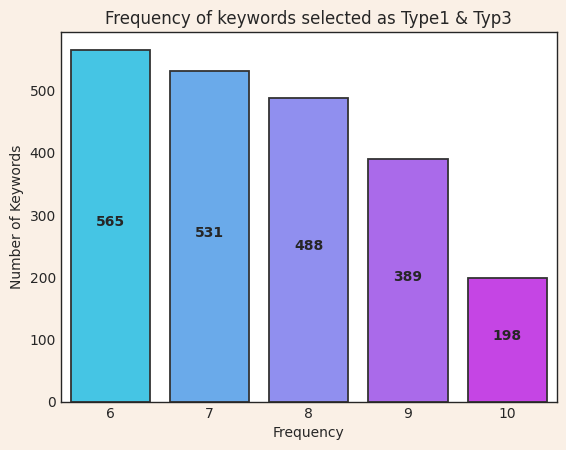

In [121]:
import seaborn as sns

x = [j for j in range(6, 11)]
counts = []

fig = plt.figure(facecolor='linen')

for i in range(6, 11):
    counts.append(len([k for k, v in keyword_frequency.items() if v >= i]))

sns.set_style("white")
palette = sns.color_palette("cool", len(x))

barplot = sns.barplot(x = x, y=counts, palette=palette, linewidth=1.3, edgecolor=".2")

for idx, val in enumerate(counts):
    barplot.text(idx, val/2, val, ha='center', weight = 'bold')


plt.title('Frequency of keywords selected as Type1 & Typ3')
plt.xlabel('Frequency')
plt.ylabel('Number of Keywords')
plt.show()

In [122]:
select_keywords_list = select_intersection_list
extract_keywords_list = extract_intersection_list

In [123]:
print("Core-word feature Document 갯수:",tfidf_matrix.shape[0])
print("Core-word feature Document word-feature 갯수:",tfidf_matrix.shape[1])

Core-word feature Document 갯수: 997
Core-word feature Document word-feature 갯수: 700


In [124]:
# Stopword list를 생성하기 위한 Check 지표
checking_1= pd.DataFrame(select_keywords_list, columns = ['keyword'])
checking_1.to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/final_select_keyword.csv', index=False)

checking_2 = pd.DataFrame(extract_keywords_list, columns = ['keyword'])
checking_2.to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/stopwords.csv', index=False)

### Eliminated outliers by calculating the cosine similarities(Entire dataset)

In [125]:
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out(), index=df.index)

cosine_sim = cosine_similarity(tfidf_df) - np.eye(tfidf_df.shape[0])
mean_cosine_sim = np.mean(cosine_sim, axis=1)

df_cosine_sim = pd.DataFrame(mean_cosine_sim, columns=['Mean Cosine Similarity'], index=df.index)
df_sorted = df_cosine_sim.sort_values(by='Mean Cosine Similarity')

bottom_100_indices_and_values = df_sorted.head(100)

bottom_100_titles = df.loc[bottom_100_indices_and_values.index, 'Article Title']
bottom_100_titles.to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/Eliminated_documents.csv', index=False)

# del document
print("최종 선정 Document 갯수:",tfidf_matrix.shape[0])
print("최종 선정 word-feature 갯수:",tfidf_matrix.shape[1])

최종 선정 Document 갯수: 997
최종 선정 word-feature 갯수: 700


## STEP 2 : Descriptive analysis

### Word analysis

### find Top 10 Research Areas and Journals Related to Smart Home Service

### Word association rule mining

## STEP 3 : Unsupervised machine learning

### Principal component analysis(PCA)

In [126]:
vectorizer = TfidfVectorizer(vocabulary=select_keywords_list)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])

Number of components for 95% variance: 323


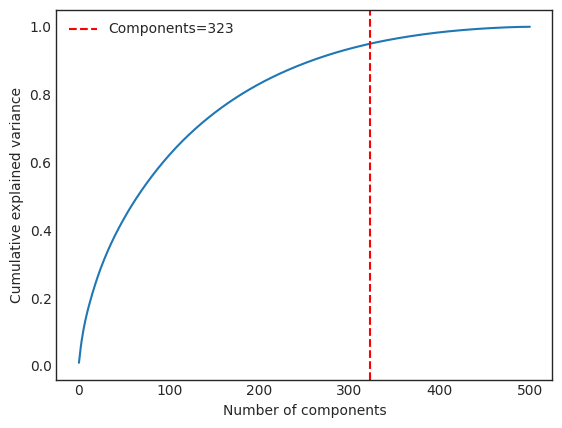

In [127]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import numpy as np

X = tfidf_matrix

svd = TruncatedSVD(n_components=X.shape[1]-1)
svd.fit(X)

cumulative_explained_variance = np.cumsum(svd.explained_variance_ratio_)

n_components = np.where(cumulative_explained_variance > 0.95)[0][0]

print(f"Number of components for 95% variance: {n_components}")

plt.plot(cumulative_explained_variance)
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.axvline(x=n_components, color='r', linestyle='--', label=f'Components={n_components}')
plt.legend()
plt.show()

### Spectral Clustering

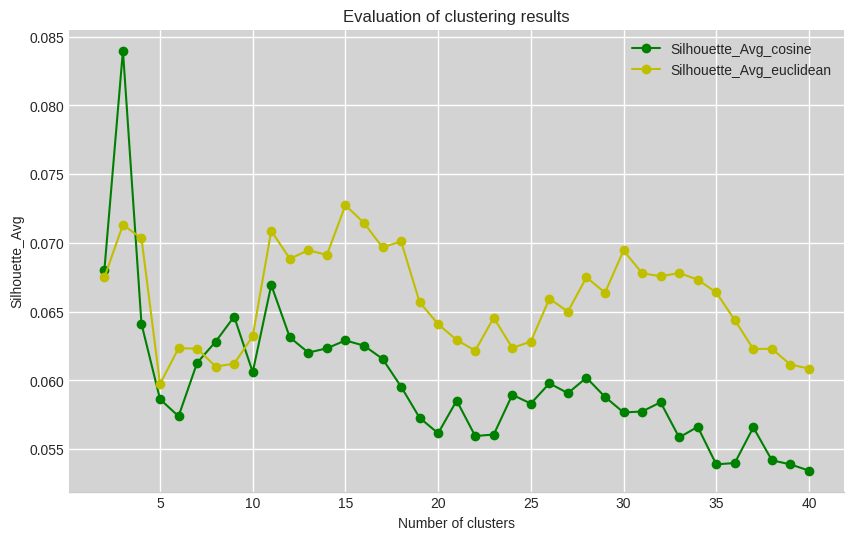

In [157]:
# find optimal cluster numbers
svd = TruncatedSVD(n_components=n_components)
tfidf_matrix_svd = svd.fit_transform(tfidf_matrix)

metrics = ['cosine', 'euclidean']
cluster_range = range(2, 41)

results = {}

for metric in metrics:
    results[metric] = []

    if metric == 'cosine':
        affinity = 'precomputed'
        sim_matrix = cosine_similarity(tfidf_matrix)

    elif metric == 'euclidean':
        distance_matrix = euclidean_distances(tfidf_matrix)
        sigma = np.mean(distance_matrix)
        sim_matrix = np.exp(-distance_matrix ** 2 / (2. * sigma ** 2))


    for n_clusters in cluster_range:
        silhouette_avg_list = []

        # Spectral Clustering 실행 (10번 반복)
        for _ in range(10):
            sc = SpectralClustering(n_clusters=n_clusters, affinity = affinity).fit(sim_matrix)
            labels=sc.labels_

            silhouette_avg_list.append(silhouette_score(sim_matrix, labels))

        results[metric].append(np.mean(silhouette_avg_list))

plt.style.use('seaborn-whitegrid')
plt.figure(figsize=(10,6))

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.gca().set_facecolor('lightgray')
plt.grid(color='white', linestyle='-', linewidth=1)

for metric in metrics:

    if metric == 'cosine':
        color = 'g'
    elif metric == 'euclidean':
        color = 'y'

    plt.plot(cluster_range, results[metric], label=f'Silhouette_Avg_{metric}', marker='o', color = color)

plt.title('Evaluation of clustering results')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette_Avg')
plt.legend()
plt.show()

## STEP 4 : Interpreting the clusters

### Simple analysis (F-values, chi_squared)

In [149]:
n_clusters = 16

vectorizer = TfidfVectorizer(vocabulary=select_keywords_list)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])

# svd = TruncatedSVD(n_components=n_components)
# tfidf_matrix_svd = svd.fit_transform(tfidf_matrix)

affinity = 'precomputed'
sim_matrix = cosine_similarity(tfidf_matrix)

clustering = SpectralClustering(n_clusters=n_clusters, affinity = affinity).fit(sim_matrix)

labels = clustering.labels_

kbest_chi2 = SelectKBest(score_func=chi2, k=100)
kbest_chi2.fit(tfidf_matrix, labels)
word_features_chi2 = np.array(kbest_chi2.get_support(indices=True))

kbest_f = SelectKBest(score_func=f_classif, k=100)
kbest_f.fit(tfidf_matrix, labels)
word_features_f = np.array(kbest_f.get_support(indices=True))

word_features = set(word_features_chi2) & set(word_features_f)
print("Top 100 Word-Features with Clear Differences among Clusters:")

feature_names = vectorizer.get_feature_names_out()
for feature_index in word_features:
    print(feature_names[feature_index])

Top 100 Word-Features with Clear Differences among Clusters:
scheme
human
thing
traffic
secure
adoption
gateway
ontology
edge
medical
speaker
aware
public
concurrent
web
context
eshs
network
device
protocol
grid
computing
energy
factor
activity
data
osgi
care
latency
cloud
perceived
object
intention
bundle
consumer
sensor
conflict
privacy
elderly
password
electricity
power
resolution
acceptance
wireless
city
upnp
security
electric
sip
health
community
open
scheduling
iot
consumption
priority
preserving
robot
recognition
qos
risk
hem
key
patient
eco
bandwidth
voice
user
reasoning
system
fog
healthcare
attack
jini
living
authentication
cognition


### Topic modeling(NMF & LDA)

In [150]:
from collections import Counter

cluster_counts = Counter(labels)

for cluster, count in cluster_counts.items():
    print(f"클러스터 {cluster}: {count}개의 문서")

클러스터 4: 141개의 문서
클러스터 0: 135개의 문서
클러스터 5: 133개의 문서
클러스터 1: 85개의 문서
클러스터 2: 72개의 문서
클러스터 10: 51개의 문서
클러스터 8: 20개의 문서
클러스터 12: 57개의 문서
클러스터 11: 53개의 문서
클러스터 13: 48개의 문서
클러스터 7: 40개의 문서
클러스터 3: 25개의 문서
클러스터 14: 22개의 문서
클러스터 6: 42개의 문서
클러스터 9: 56개의 문서
클러스터 15: 17개의 문서


In [151]:
n_topics = 1

nmf = NMF(n_components=n_topics, random_state=0)
nmf_topics = []

for i in range(n_clusters):
    cluster_data = X[labels == i]

    nmf.fit(cluster_data)
    nmf_topic_words = nmf.components_.argsort()[:, ::-1]
    nmf_topics.append(nmf_topic_words)

lda = LatentDirichletAllocation(n_components=n_topics, random_state=0)
lda_topics = []

for i in range(n_clusters):
    cluster_data = X[labels == i]

    lda.fit(cluster_data)
    lda_topic_words = lda.components_.argsort()[:, ::-1]
    lda_topics.append(lda_topic_words)

n_top_words = 20  # 상위 키워드 수를 설정합니다. 원하는 수로 변경 가능합니다.

for i in range(n_clusters):
    print("Cluster %d:" % i)

    for j in range(n_topics):
        print("NMF Topic %d:" % j, [vectorizer.get_feature_names_out()[index] for index in nmf_topics[i][j, :n_top_words]])
        print("LDA Topic %d:" % j, [vectorizer.get_feature_names_out()[index] for index in lda_topics[i][j, :n_top_words]])
        print("  ")

Cluster 0:
NMF Topic 0: ['home', 'device', 'smart', 'user', 'service', 'environment', 'system', 'framework', 'based', 'interaction', 'architecture', 'control', 'appliance', 'interface', 'proposed', 'process', 'information', 'intelligent', 'ontology', 'automation']
LDA Topic 0: ['home', 'device', 'smart', 'service', 'user', 'system', 'environment', 'framework', 'based', 'architecture', 'interaction', 'appliance', 'control', 'interface', 'ontology', 'tv', 'proposed', 'content', 'process', 'information']
  
Cluster 1:
NMF Topic 0: ['iot', 'smart', 'home', 'thing', 'service', 'device', 'internet', 'security', 'web', 'based', 'application', 'object', 'system', 'data', 'technology', 'architecture', 'model', 'platform', 'user', 'environment']
LDA Topic 0: ['iot', 'smart', 'home', 'thing', 'service', 'device', 'internet', 'web', 'security', 'based', 'application', 'object', 'data', 'system', 'model', 'architecture', 'technology', 'platform', 'user', 'environment']
  
Cluster 2:
NMF Topic 0: ['


### Visualization(Longabaugh, 2012)

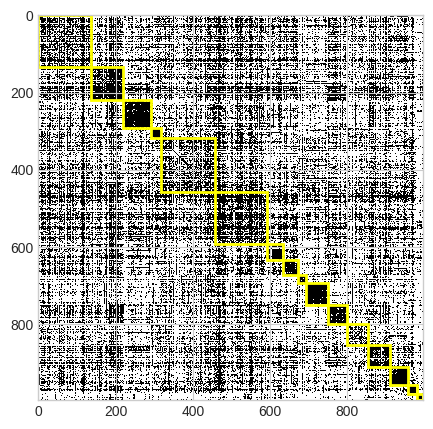

In [152]:
import networkx as nx
from matplotlib import pyplot, patches

cos_sim = cosine_similarity(tfidf_matrix)
mean_sim = np.mean(cos_sim)
binary_adj_matrix = np.where(cos_sim >= mean_sim, 1, 0)

node_order = np.argsort(labels)
sorted_binary_adj_matrix = binary_adj_matrix[node_order, :][:, node_order]

def draw_adjacency_matrix(G, node_order=None, partitions=[], colors=[]):
    """
    - G is a netorkx graph
    - node_order (optional) is a list of nodes, where each node in G
          appears exactly once
    - partitions is a list of node lists, where each node in G appears
          in exactly one node list
    - colors is a list of strings indicating what color each
          partition should be
    If partitions is specified, the same number of colors needs to be
    specified.
    """
    adjacency_matrix = nx.to_numpy_array(G, dtype=np.bool, nodelist=node_order)

    #Plot adjacency matrix in toned-down black and white
    fig = pyplot.figure(figsize=(5, 5)) # in inches
    pyplot.imshow(adjacency_matrix,
                  cmap="Greys",
                  interpolation="none")

    # The rest is just if you have sorted nodes by a partition and want to
    # highlight the module boundaries
    assert len(partitions) == len(colors)
    ax = pyplot.gca()
    current_idx = 0
    for partition, color in zip(partitions, colors):
        ax.add_patch(patches.Rectangle((current_idx, current_idx),
                                          len(partition), # Width
                                          len(partition), # Height
                                          facecolor="none",
                                          edgecolor=color,
                                          linewidth=2))
        current_idx += len(partition)

G = nx.from_numpy_array(sorted_binary_adj_matrix)

partitions = []
for i in range(n_clusters):
    partitions.append([idx for idx, cluster in enumerate(labels) if cluster == i])

colors = ['#FFFF00' for _ in range(n_clusters)]
draw_adjacency_matrix(G, partitions=partitions, colors=colors)

### Network analysis

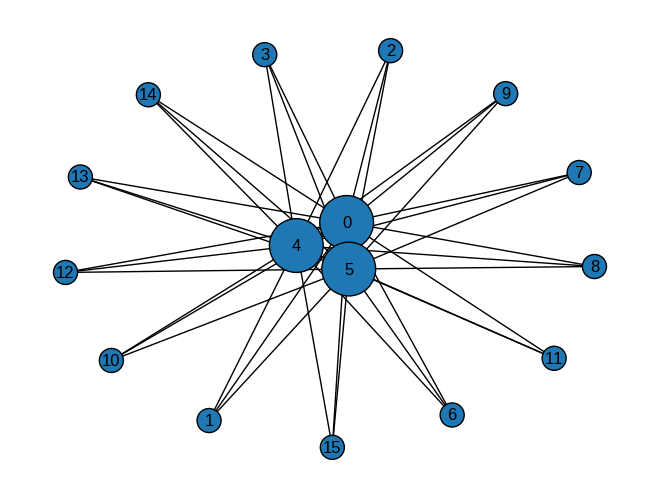

In [153]:
from operator import itemgetter
import matplotlib.cm as cm

centroids = []
for i in range(n_clusters):
    members = X[clustering.labels_ == i]
    centroid = np.median(members.toarray(), axis=0)
    centroids.append(centroid)

similarity_matrix = cosine_similarity(centroids)

# 각 클러스터에서 가장 유사한 3개의 클러스터를 찾기
top_clusters = {}
for i in range(n_clusters):
    similar_clusters = sorted(list(enumerate(similarity_matrix[i])), key=itemgetter(1), reverse=True)[1:4]
    top_clusters[i] = [idx for idx, similarity in similar_clusters]

G = nx.Graph()
for cluster, neighbors in top_clusters.items():
    for neighbor in neighbors:
        G.add_edge(cluster, neighbor)

sizes = [G.degree(node) * 100 for node in G]
colors = cm.rainbow(np.linspace(0, 1, n_clusters))
node_colors = [colors[i] for i in range(n_clusters)]

nx.draw(G, with_labels=True, node_size=sizes, edgecolors = 'black')